# Node-catalog tour: SWIR pill-tray inspection, driven by a CuvisPipeline

This notebook walks a broad slice of the **cuvis-ai** node catalog over a single
short-wave infrared (SWIR) hyperspectral acquisition of a tray of visually
near-identical white tablets, one product per compartment. Everything runs
**through the framework**: nodes are wired into a `CuvisPipeline`, the stateful
nodes are fitted with `StatisticalTrainer`, inference runs with `Predictor`, and
matplotlib only renders the `(node, port)` outputs each pipeline collected (the
same pattern as `blood_perfusion.ipynb`). We never call `node.forward(...)` by hand.

**The data.** SWIR session at
`data/Pills/swir_pills_tray_01.cu3s` (200x200 px, 39 bands, 980-1664 nm,
calibrated Reflectance). Two rotated re-scans (`swir_pills_tray_02/03`) ship
alongside. 

**The question.** In the visible range these tablets look identical (white,
round). In the SWIR the molecular overtone absorptions differ, so the question is
whether the **spectra** can separate the 16 compartments. The inspection graph is
a branched DAG:

```
CU3SDataNode ─┬─> BlobDetector ───────────────────► 16 compartments (spatial)
              │        └────────(blob mask)────────────────────────┐
              └─> ContinuumRemoval ─┬─> SpectralSignatureExtractor  │
                                    │      └─> SignaturesToReferences│
                                    │            └─> SpectralAngleMapper ─> MajorityVoteByBlob ─► clean map
                                    └─> KMeansClusterer / GaussianMixtureClusterer ─► spectral clusters
```

**Nodes shown:** `CU3SDataNode`, `BlobDetector`, `ContinuumRemoval`,
`SNVCorrection`, `SpectralDerivative`, `SavitzkyGolay`,
`SpectralSignatureExtractor`, `SignaturesToReferences`, `SpectralAngleMapper`,
`MajorityVoteByBlob`, `KMeansClusterer`, `GaussianMixtureClusterer`.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from cuvis_ai_dataloader.data import Cu3sDataModule
from IPython.display import Image, display
from loguru import logger as _loguru_logger

from cuvis_ai.node.blob_detector import BlobDetector
from cuvis_ai.node.clustering.gmm import GaussianMixtureClusterer
from cuvis_ai.node.clustering.kmeans import KMeansClusterer
from cuvis_ai.node.data import CU3SDataNode
from cuvis_ai.node.mask_ops import MajorityVoteByBlob
from cuvis_ai.node.pretreatments.continuum_removal import ContinuumRemoval
from cuvis_ai.node.pretreatments.savitzky_golay import SavitzkyGolay
from cuvis_ai.node.pretreatments.snv import SNVCorrection
from cuvis_ai.node.pretreatments.spectral_derivative import SpectralDerivative
from cuvis_ai.node.spectral_angle_mapper import SpectralAngleMapper
from cuvis_ai.node.spectral_extractor import SignaturesToReferences, SpectralSignatureExtractor
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import Predictor, StatisticalTrainer

# Quiet noisy third-party logging (cuvis SDK + dataloader) for a clean notebook.
logging.getLogger().setLevel(logging.CRITICAL)
_loguru_logger.remove()

torch.manual_seed(0)
# The SWIR cube is small (200x200x39) and every op here is light, so we run on
# CPU to keep the example reproducible and dependency-light. CUDA also works.
device = torch.device("cpu")
print("device:", device)

W0626 11:44:46.407000 46120 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


device: cpu


## 0. Data

`swir_pills_tray_01.cu3s` is the working scan (one product per compartment).
`dm()` builds a one-frame `Cu3sDataModule` in calibrated Reflectance mode; every
pipeline below is fitted and/or run against it.

In [2]:
DATA_DIR = Path("../../data/Pills")
CU3S = DATA_DIR / "swir_pills_tray_01.cu3s"
assert CU3S.exists(), f"missing {CU3S}"

# graphviz renders of each pipeline DAG land here (gitignored)
RENDER_DIR = Path("output")
RENDER_DIR.mkdir(parents=True, exist_ok=True)


def dm() -> Cu3sDataModule:
    """One-frame Reflectance Cu3sDataModule for the working pill tray."""
    return Cu3sDataModule(
        cu3s_file_path=str(CU3S),
        processing_mode="Reflectance",
        batch_size=1,
        measurement_indices=[0],
    )

## 1. Localize the compartments, then ask if their spectra differ

The **inspection pipeline** is a single branched DAG:

- `BlobDetector` reduces the cube to a brightness image, thresholds it (Otsu),
  cleans it, and labels connected components, pinning the count to the 16 tray
  compartments with `keep_largest=16`.
- `ContinuumRemoval` divides each spectrum by its upper convex hull, isolating
  the absorption-feature shape from the excipient-dominated baseline.
- `SpectralSignatureExtractor` averages the continuum-removed spectra inside each
  blob; `SignaturesToReferences` turns those into one reference per compartment;
  `SpectralAngleMapper` scores every pixel against all 16 references; and
  `MajorityVoteByBlob` collapses the noisy per-pixel labels to one label per
  compartment.

`BlobDetector` reads brightness from the raw cube (continuum removal flattens the
brightness it needs), so the cube fans out to both branches. `wavelengths` is
wired explicitly from the data node (it carries the numpy dtype the nodes expect).
All nodes here are stateless, so a single `Predictor` run drives the whole graph.

In [3]:
data = CU3SDataNode(name="data")
blobs = BlobDetector(
    brightness="band_mean",
    threshold_method="otsu",
    min_area=150,
    opening_kernel=3,
    closing_kernel=3,
    keep_largest=16,
    name="blobs",
)
continuum = ContinuumRemoval(name="continuum")
signatures = SpectralSignatureExtractor(name="signatures")
references = SignaturesToReferences(name="references")
sam = SpectralAngleMapper(num_channels=39, name="sam")
vote = MajorityVoteByBlob(name="vote")

inspect = CuvisPipeline("pill_inspection")
inspect.connect(
    (data.outputs.cube, blobs.inputs.cube),
    (data.outputs.wavelengths, blobs.inputs.wavelengths),
    (data.outputs.cube, continuum.inputs.cube),
    (data.outputs.wavelengths, continuum.inputs.wavelengths),
    (continuum.outputs.cube, signatures.inputs.cube),
    (data.outputs.wavelengths, signatures.inputs.wavelengths),
    (blobs.outputs.mask, signatures.inputs.mask),
    (signatures.outputs.signatures, references.inputs.signatures),
    (continuum.outputs.cube, sam.inputs.cube),
    (references.outputs.spectral_signature, sam.inputs.spectral_signature),
    (sam.outputs.identity_mask, vote.inputs.identity_mask),
    (blobs.outputs.mask, vote.inputs.blob_mask),
)
inspect.to(device)

pill_inspection:
CU3SDataNode()
BlobDetector()
ContinuumRemoval()
SpectralSignatureExtractor()
SignaturesToReferences()
SpectralAngleMapper()
MajorityVoteByBlob()
Use `pipeline.visualize()` for Graphviz/Mermaid output.

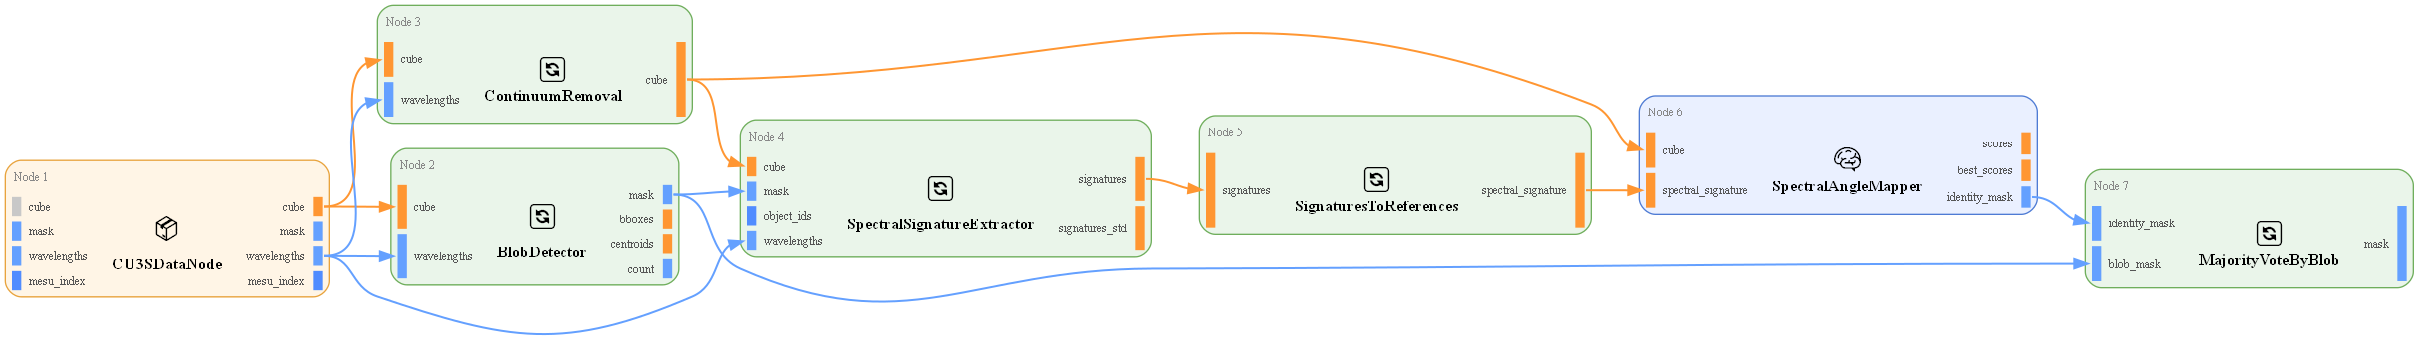

In [4]:
graph_png = inspect.visualize(
    format="render_graphviz",
    output_path=str(RENDER_DIR / f"{inspect.name}.png"),
)
display(Image(str(graph_png)))

In [5]:
out = Predictor(pipeline=inspect, datamodule=dm()).predict(collect_outputs=True)[0]
print("collected:", [f"{n}.{p}" for (n, p) in out.keys()])

cube = out[("data", "cube")]
wavelengths = np.asarray(out[("data", "wavelengths")]).ravel()
blob_mask = out[("blobs", "mask")][0].cpu().numpy()
sam_best = out[("sam", "best_scores")][0, :, :, 0].cpu().numpy()
sam_ident = out[("sam", "identity_mask")][0].cpu().numpy()
voted = out[("vote", "mask")][0].cpu().numpy()
n_blobs = int(out[("blobs", "count")].item())
n_labels = len([v for v in np.unique(voted) if v != 0])
print(f"compartments detected: {n_blobs} | distinct labels after vote: {n_labels}")

Predict [pill_inspection]:   0%|          | 0/1 [00:00<?, ?batch/s]

collected: ['data.cube', 'data.wavelengths', 'data.mesu_index', 'blobs.mask', 'blobs.bboxes', 'blobs.centroids', 'blobs.count', 'continuum.cube', 'signatures.signatures', 'signatures.signatures_std', 'references.spectral_signature', 'sam.scores', 'sam.best_scores', 'sam.identity_mask', 'vote.mask']
compartments detected: 16 | distinct labels after vote: 16


## 2. Inspection results

All six panels come from the single pipeline run above. The per-pixel Spectral
Angle Mapper labels are soft (the excipient dominates any single pixel), but the
per-blob majority vote denoises them to a clean one-label-per-compartment map.
That every compartment recovers a distinct label means the 16 products are
mutually separable **within this scan** (each compartment's own mean spectrum is
its reference).

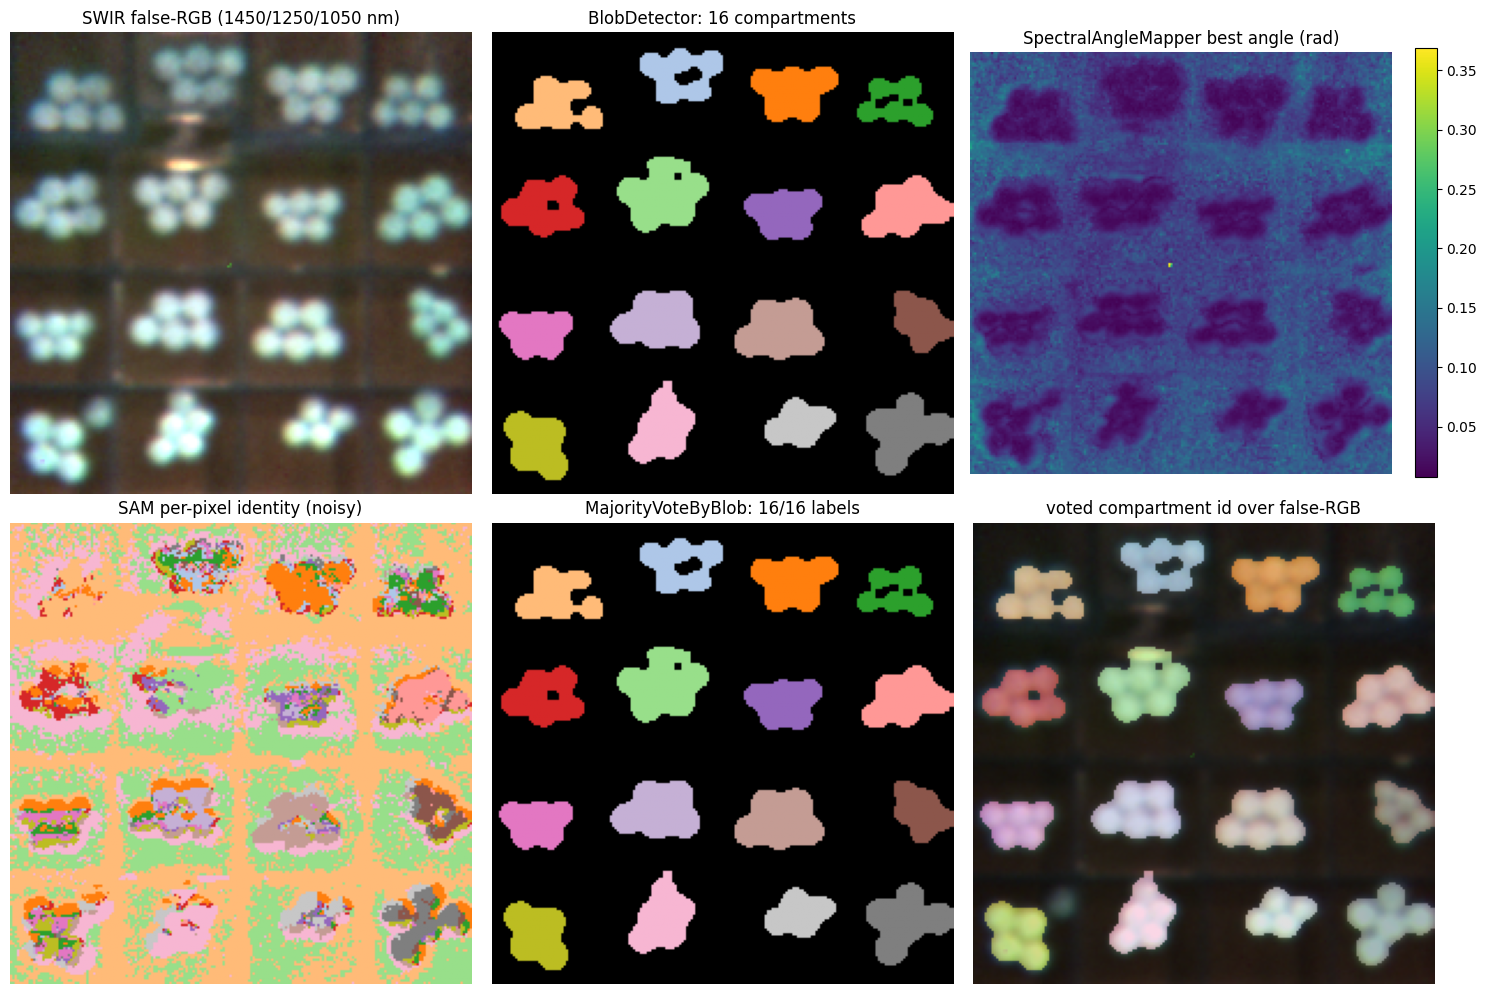

In [6]:
def false_rgb(cube_t: torch.Tensor) -> np.ndarray:
    """SWIR false-colour image from the bands nearest 1450 / 1250 / 1050 nm."""

    def pick(nm: float) -> int:
        return int(np.argmin(np.abs(wavelengths - nm)))

    img = cube_t[0, :, :, [pick(1450), pick(1250), pick(1050)]].cpu().numpy()
    return np.clip(img / max(np.percentile(img, 99), 1e-6), 0, 1)


def labels_img(label_map: np.ndarray) -> np.ma.MaskedArray:
    """Mask background (0) so label maps render it as black."""
    return np.ma.masked_where(label_map == 0, label_map)


cmap = plt.get_cmap("tab20").copy()
cmap.set_bad("black")
rgb = false_rgb(cube)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax[0, 0].imshow(rgb)
ax[0, 0].set_title("SWIR false-RGB (1450/1250/1050 nm)")

ax[0, 1].imshow(labels_img(blob_mask), cmap=cmap, vmin=0, vmax=20)
ax[0, 1].set_title(f"BlobDetector: {n_blobs} compartments")

im = ax[0, 2].imshow(sam_best, cmap="viridis")
ax[0, 2].set_title("SpectralAngleMapper best angle (rad)")
plt.colorbar(im, ax=ax[0, 2], fraction=0.046)

ax[1, 0].imshow(labels_img(sam_ident), cmap=cmap, vmin=0, vmax=20)
ax[1, 0].set_title("SAM per-pixel identity (noisy)")

ax[1, 1].imshow(labels_img(voted), cmap=cmap, vmin=0, vmax=20)
ax[1, 1].set_title(f"MajorityVoteByBlob: {n_labels}/{n_blobs} labels")

ax[1, 2].imshow(rgb)
ax[1, 2].imshow(labels_img(voted), cmap=cmap, vmin=0, vmax=20, alpha=0.55)
ax[1, 2].set_title("voted compartment id over false-RGB")

for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

## 3. Why continuum removal? A pretreatment comparison

The compartments overlap in calibrated reflectance because a tablet is mostly
common excipient (lactose, cellulose), so the bulk reflectance is dominated by
the filler and the discriminating active-ingredient absorptions are a small
overlay. This pipeline runs four pretreatment nodes off the same cube, and we
average each transform inside the 16 blobs to compare per-compartment mean
spectra. `SNVCorrection` needs no wavelengths; `ContinuumRemoval`,
`SpectralDerivative`, and `SavitzkyGolay` take them from the data node.

In [7]:
pre_data = CU3SDataNode(name="data")
pre_blobs = BlobDetector(threshold_method="otsu", min_area=150, keep_largest=16, name="blobs")
snv = SNVCorrection(name="snv")
cr = ContinuumRemoval(name="continuum")
deriv2 = SpectralDerivative(order=2, name="deriv2")
savgol = SavitzkyGolay(name="savgol")

pretreat = CuvisPipeline("pill_pretreatments")
pretreat.connect(
    (pre_data.outputs.cube, pre_blobs.inputs.cube),
    (pre_data.outputs.wavelengths, pre_blobs.inputs.wavelengths),
    (pre_data.outputs.cube, snv.inputs.cube),
    (pre_data.outputs.cube, cr.inputs.cube),
    (pre_data.outputs.wavelengths, cr.inputs.wavelengths),
    (pre_data.outputs.cube, deriv2.inputs.cube),
    (pre_data.outputs.wavelengths, deriv2.inputs.wavelengths),
    (pre_data.outputs.cube, savgol.inputs.cube),
    (pre_data.outputs.wavelengths, savgol.inputs.wavelengths),
)
pretreat.to(device)

pill_pretreatments:
CU3SDataNode()
BlobDetector()
SNVCorrection()
ContinuumRemoval()
SpectralDerivative()
SavitzkyGolay()
Use `pipeline.visualize()` for Graphviz/Mermaid output.

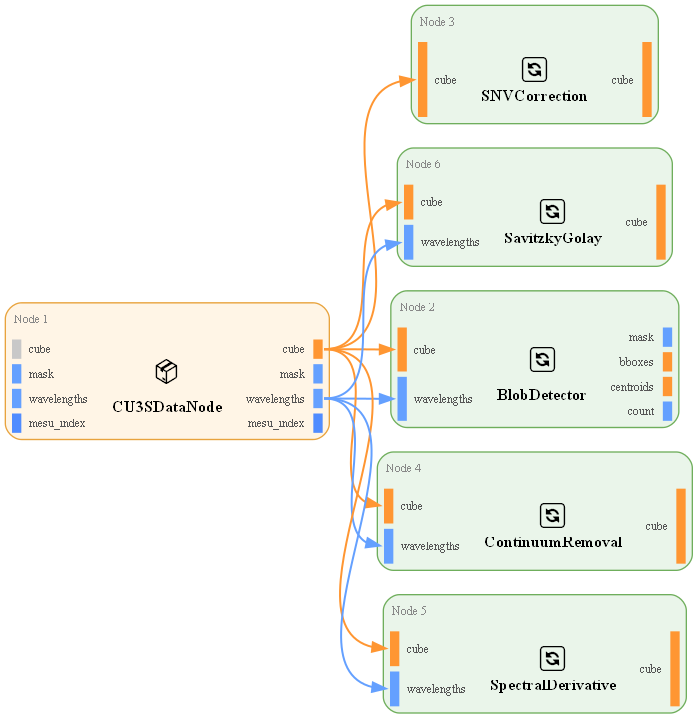

In [8]:
graph_png = pretreat.visualize(
    format="render_graphviz",
    output_path=str(RENDER_DIR / f"{pretreat.name}.png"),
)
display(Image(str(graph_png)))

Predict [pill_pretreatments]:   0%|          | 0/1 [00:00<?, ?batch/s]

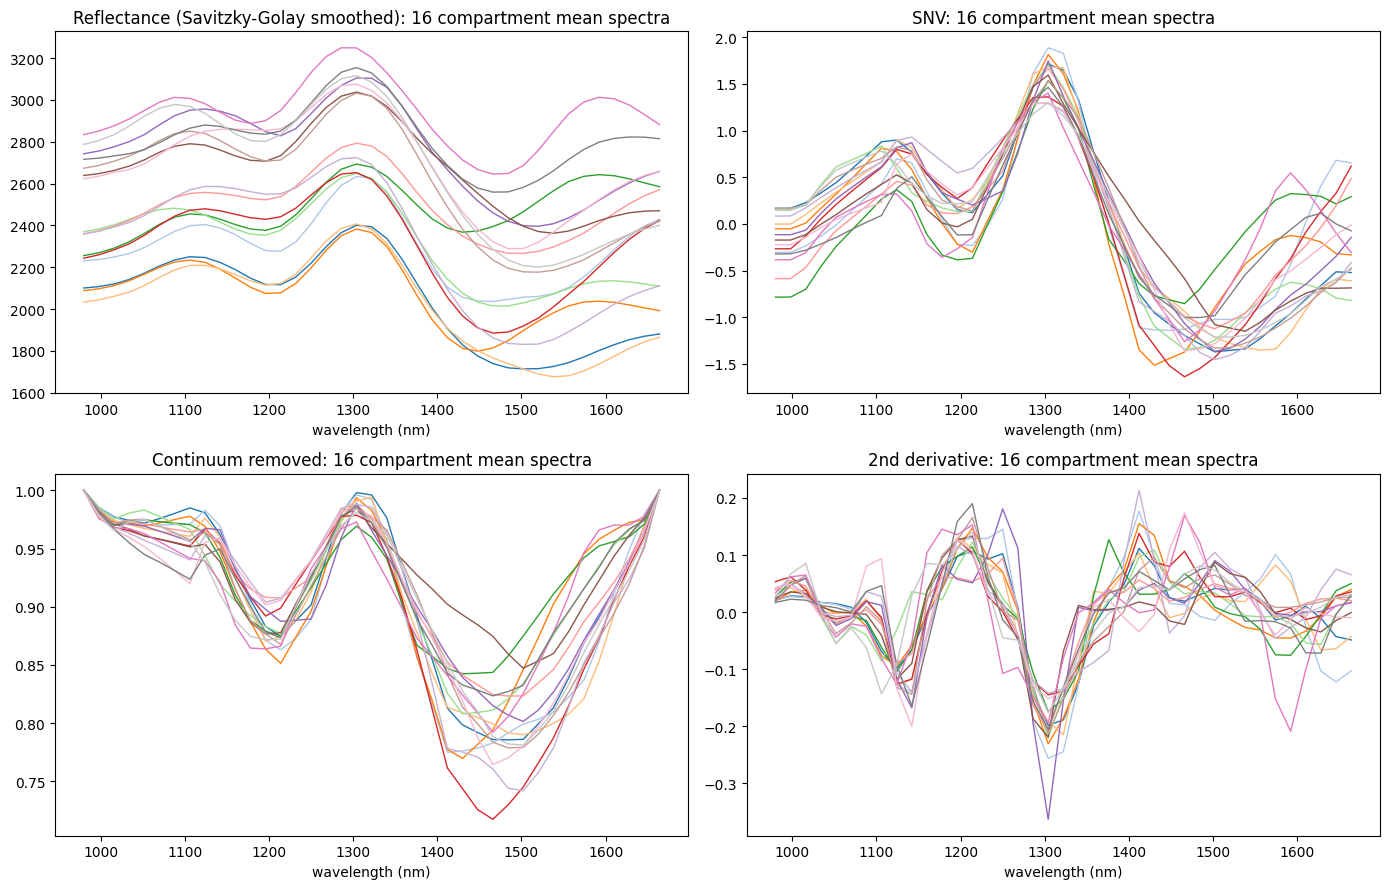

In [9]:
pre = Predictor(pipeline=pretreat, datamodule=dm()).predict(collect_outputs=True)[0]

pre_mask = pre[("blobs", "mask")][0].cpu().numpy()
ids = [i for i in np.unique(pre_mask) if i != 0]
panels = {
    "Reflectance (Savitzky-Golay smoothed)": pre[("savgol", "cube")],
    "SNV": pre[("snv", "cube")],
    "Continuum removed": pre[("continuum", "cube")],
    "2nd derivative": pre[("deriv2", "cube")],
}

fig, ax = plt.subplots(2, 2, figsize=(14, 9))
line_cmap = plt.get_cmap("tab20")
for axis, (title, cube_t) in zip(ax.ravel(), panels.items(), strict=True):
    arr = cube_t[0].cpu().numpy()
    for k, blob_id in enumerate(ids):
        spec = arr[pre_mask == blob_id].mean(axis=0)
        axis.plot(wavelengths, spec, color=line_cmap(k % 20), linewidth=1.0)
    axis.set_title(f"{title}: 16 compartment mean spectra")
    axis.set_xlabel("wavelength (nm)")
plt.tight_layout()
plt.show()

## 4. Unsupervised spectral clustering

A cross-check that needs no references: cluster the continuum-removed pixels
directly. `KMeansClusterer` and `GaussianMixtureClusterer` are fitted on the same
frame with `StatisticalTrainer` (both are `requires_initial_fit` nodes), then the
graph is run with `Predictor`. The clusters fall along the compartment layout,
the same structure the supervised self-ID map recovered.

In [10]:
clu_data = CU3SDataNode(name="data")
clu_cr = ContinuumRemoval(name="continuum")
kmeans = KMeansClusterer(n_clusters=8, random_state=0, name="kmeans")
gmm = GaussianMixtureClusterer(n_components=8, random_state=0, name="gmm")

cluster = CuvisPipeline("pill_clustering")
cluster.connect(
    (clu_data.outputs.cube, clu_cr.inputs.cube),
    (clu_data.outputs.wavelengths, clu_cr.inputs.wavelengths),
    (clu_cr.outputs.cube, kmeans.inputs.cube),
    (clu_cr.outputs.cube, gmm.inputs.cube),
)
cluster.to(device)

pill_clustering:
CU3SDataNode()
ContinuumRemoval()
KMeansClusterer()
GaussianMixtureClusterer()
Use `pipeline.visualize()` for Graphviz/Mermaid output.

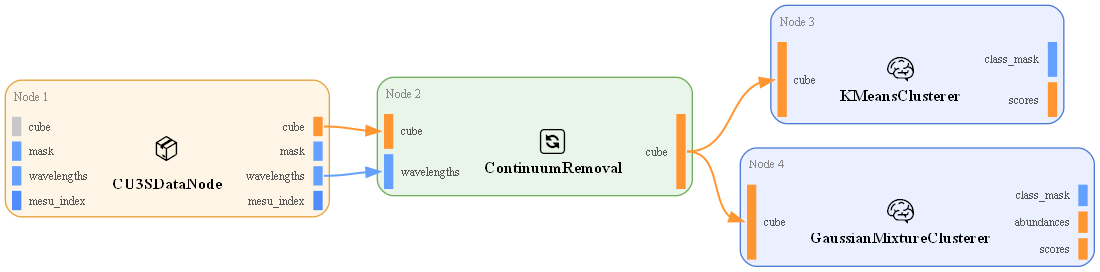

In [11]:
graph_png = cluster.visualize(
    format="render_graphviz",
    output_path=str(RENDER_DIR / f"{cluster.name}.png"),
)
display(Image(str(graph_png)))

Predict [pill_clustering]:   0%|          | 0/1 [00:00<?, ?batch/s]

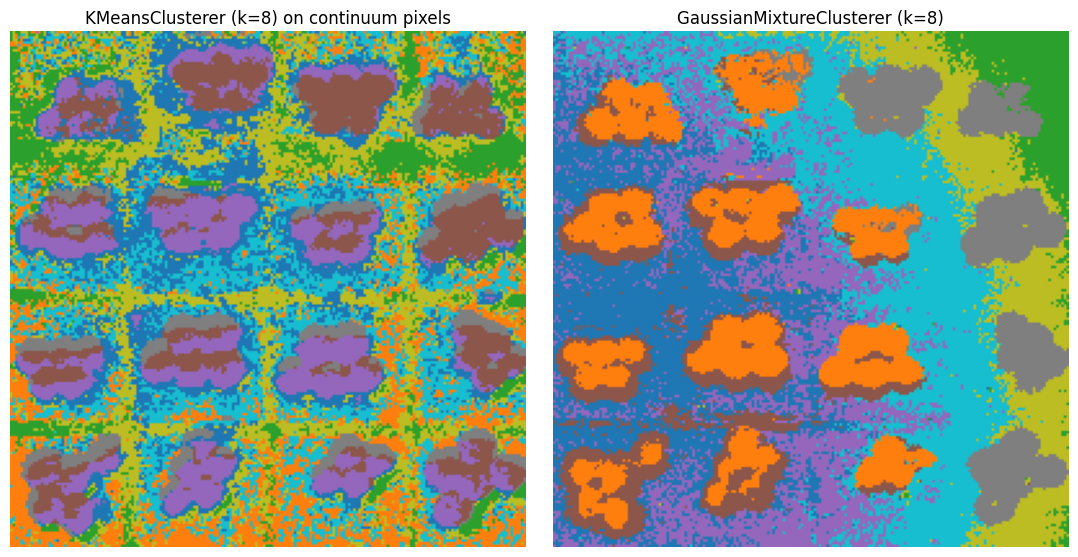

In [12]:
StatisticalTrainer(pipeline=cluster, datamodule=dm()).fit()
clu = Predictor(pipeline=cluster, datamodule=dm()).predict(collect_outputs=True)[0]
km_map = clu[("kmeans", "class_mask")][0].cpu().numpy()
gmm_map = clu[("gmm", "class_mask")][0].cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
ax[0].imshow(km_map, cmap="tab10")
ax[0].set_title("KMeansClusterer (k=8) on continuum pixels")
ax[1].imshow(gmm_map, cmap="tab10")
ax[1].set_title("GaussianMixtureClusterer (k=8)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

## Notes

- Every result above came through the framework: `StatisticalTrainer.fit()` for
  the clustering nodes and `Predictor.predict(collect_outputs=True)` for
  inference, the same path a `restore-trainrun` config drives in production.
- `BlobDetector`, `SignaturesToReferences`, and `MajorityVoteByBlob` are
  pure-torch nodes added to the catalog for this kind of object-level
  inspection; `BlobDetector` reuses the shared OpenCV connected-components helper
  rather than a second hand-rolled labeller.
- **Honest scope:** the clean per-compartment map shows the 16 products are
  separable *within a single scan*, where each compartment is its own reference.
  Transferring those references to a physically re-placed (rotated) tray is a
  much harder problem, illumination and geometry shift each spectrum by more than
  the thin inter-product margin, so cross-scan transfer is not claimed here.
- Swap `ContinuumRemoval` for `SpectralDerivative` to retune the same graph for a
  concentration gradient (same drug at different dosages), where band *depth*,
  not feature *shape*, carries the signal.